Generate the Member Population

In [1]:
import numpy as np
import pandas as pd

# Random seed for reproducability
np.random.seed(42)

# Population size
NUM_MEMBERS = 1000

# Random ages uniformly distributed between 25 and 65
ages = np.random.randint(25, 66, NUM_MEMBERS)

# Random years of service using simple assumption, range 0, age - 22
years_service = np.array([
    np.random.randint(0, age - 21)
    for age in ages
])

# Random salaries, mean 35000, std 8000
salaries = np.random.normal(
    loc=35000,
    scale=8000,
    size=NUM_MEMBERS
)
salaries = np.clip(salaries, 18000, 120000)

## 50 50 gender split
genders = np.random.choice(
    ["Male", "Female"],
    size=NUM_MEMBERS
)

## Create data frame
members = pd.DataFrame({
    "Member_ID": np.arange(1, NUM_MEMBERS + 1),
    "Age": ages,
    "Years_of_Service": years_service,
    "Salary": salaries.round(2),
    "Gender": genders
})

# Save to file
members.to_csv("members.csv", index=False)

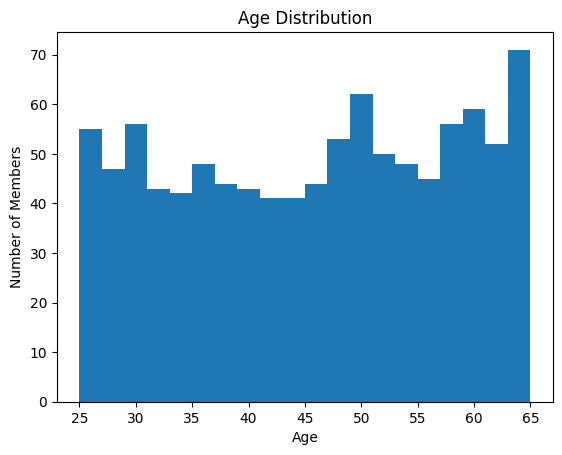

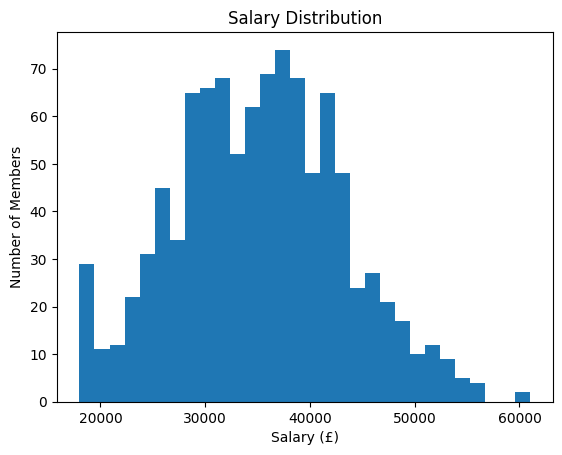

In [2]:
# Validate that synthetic data is realistic
import matplotlib.pyplot as plt

plt.hist(members["Age"], bins=20)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Members")
plt.show()

plt.hist(members["Salary"], bins=30)
plt.title("Salary Distribution")
plt.xlabel("Salary (£)")
plt.ylabel("Number of Members")
plt.show()

Model Salary Growth

In [ ]:
# For each member start with their current salary, project forward one year at a time until 65.
# Each year growth consists of a base rate of 2.5 percent + random shock N(0, 1) percent
# Formula: salary(t+1) = salary(t) * (1.025 + N(0, 0.01))

# Load dataset
members = pd.read_csv("members.csv")

# Paramters
RETIREMENT_AGE = 65
BASE_GROWTH = 0.025
SHOCK_STD = 0.01

# Function to project salary
def project_salary(current_salary, current_age, retirement_age=RETIREMENT_AGE, base_growth=BASE_GROWTH, shock_std=SHOCK_STD):

    salary = current_salary
    years = retirement_age - current_age

    for _ in range(years):
        shock = np.random.normal(0, shock_std)
        growth = base_growth + shock
        salary *= (1 + growth)

    return salary

# Apply the function to every member
members["Final_Salary"] = members.apply(
    lambda row: project_salary(row["Salary"], row["Age"]),
    axis=1
)
members["Final_Salary"] = members["Final_Salary"].round(2)

# Calculate salary growth for each member
members["Salary_Growth_%"] = ((members["Final_Salary"] - members["Salary"])/ members["Salary"] * 100
).round(1)

members.to_csv("members.csv", index=False)

In [ ]:
# Average salary growth
average_growth = (
    members["Final_Salary"].mean()
    - members["Salary"].mean()
)

print(f"Average salary increase: £{average_growth:,.2f}")

Average salary increase: £24,359.06


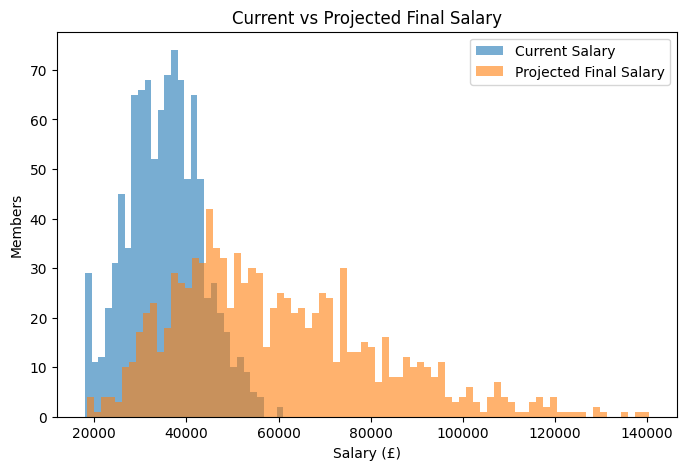

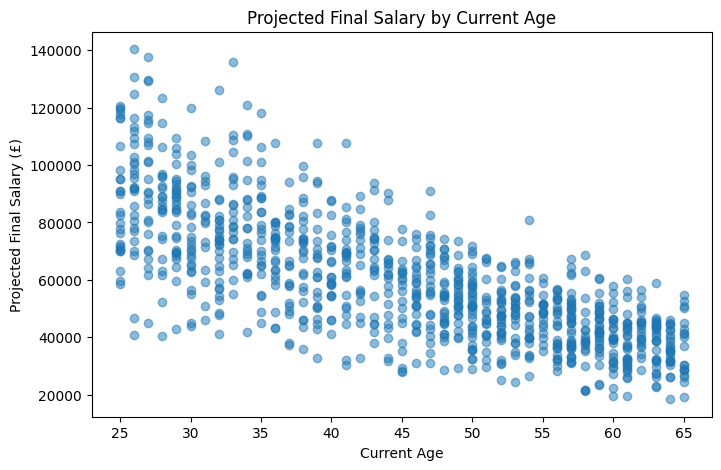

In [ ]:
# Visualise current vs final salaries
plt.figure(figsize=(8,5))

plt.hist(members["Salary"], bins=30, alpha=0.6, label="Current Salary")
plt.hist(members["Final_Salary"], bins=80, alpha=0.6, label="Projected Final Salary")

plt.xlabel("Salary (£)")
plt.ylabel("Members")
plt.title("Current vs Projected Final Salary")
plt.legend()
plt.show()

# Visualise salary growth by age
plt.figure(figsize=(8,5))

plt.scatter(members["Age"], members["Final_Salary"], alpha=0.5)

plt.xlabel("Current Age")
plt.ylabel("Projected Final Salary (£)")
plt.title("Projected Final Salary by Current Age")
plt.show()

Model Member Longevity

In [ ]:
# For each member, retire at 65, simulate how many years they live after retirement, calculate their age at death.
# Determine how many annual pension payments they receive

# Load dataset
members = pd.read_csv("members.csv")

# Parameters
RETIREMENT_AGE = 65

MEAN_POST_RETIREMENT = 20
STD_POST_RETIREMENT = 5

# Generate Post-Retirement Lifespans, one per member
post_retirement_years = np.random.normal(loc=MEAN_POST_RETIREMENT, scale=STD_POST_RETIREMENT, size=len(members))

# To avoid unrealistic values, assume everyone lives at least 5 years after retirement and no more than 40 years.
post_retirement_years = np.clip(post_retirement_years, 5, 40)
post_retirement_years = np.round(post_retirement_years).astype(int)

# Add data to dataset
members["Years_in_Retirement"] = post_retirement_years
members["Age_at_Death"] = (RETIREMENT_AGE + members["Years_in_Retirement"])

print(
    f"Average years in retirement: "
    f"{members['Years_in_Retirement'].mean():.2f}"
)

members.to_csv("members.csv",index=False)

Average years in retirement: 20.01


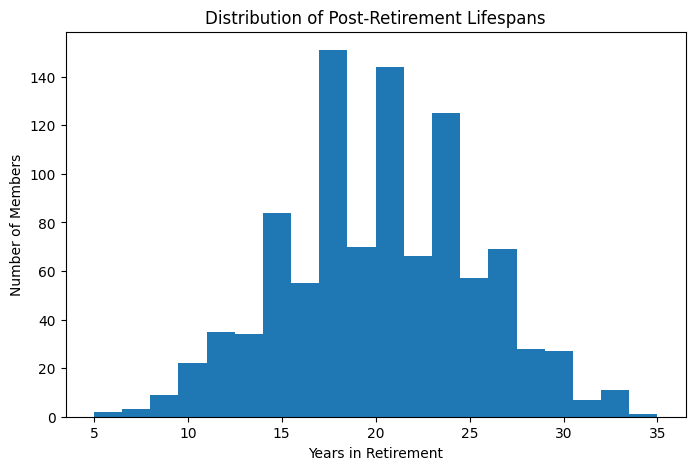

In [ ]:
# Visualise the Distribution of years in retirement

plt.figure(figsize=(8,5))

plt.hist(members["Years_in_Retirement"], bins=20)

plt.xlabel("Years in Retirement")
plt.ylabel("Number of Members")
plt.title("Distribution of Post-Retirement Lifespans")

plt.show()

Model Discount Rates

In [ ]:
# Create a stochastic discount rate model where:
# Long-run average discount rate = 3.5%
# Rates move randomly each year
# Rates tend back towards the long-run average

# Formula: Rate(t+1) = Rate(t) + a(r - Rate(t)) + Random volitility * Random shock
# a = Speed of mean reversion
# r = Long-run average rate

# Parameters
LONG_RUN_RATE = 0.035
INITIAL_RATE = 0.035 # Starting rate
MEAN_REVERSION_SPEED = 0.25
RATE_VOLATILITY = 0.01

# Generate one possible future interest rate path.
def simulate_discount_rates(years, initial_rate=INITIAL_RATE, long_run_rate=LONG_RUN_RATE, mean_reversion=MEAN_REVERSION_SPEED, volatility=RATE_VOLATILITY):

    rates = np.zeros(years)
    rates[0] = initial_rate

    for t in range(1, years):
        shock = np.random.normal(0, volatility)
        rates[t] = (rates[t-1] + mean_reversion * (long_run_rate - rates[t-1]) + shock)
        # Prevent rates from falling below 0.5 percent
        rates[t] = max(rates[t], 0.005)

    return rates

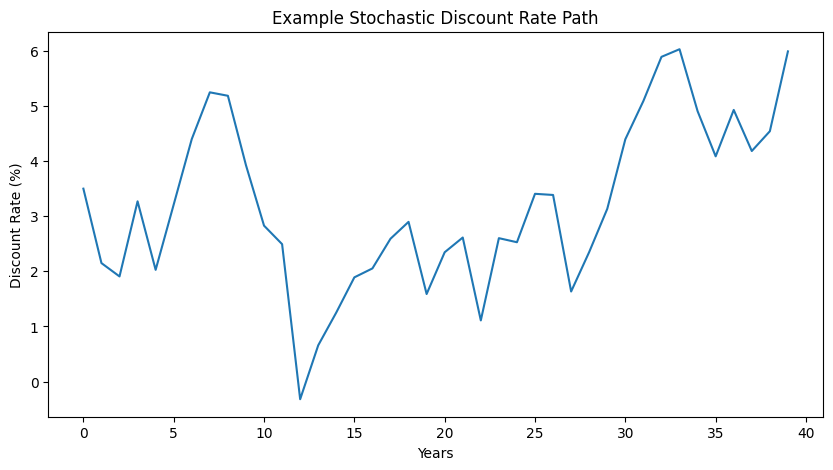

In [ ]:
# Visualise the 40 year Interest Rate Path
rates = simulate_discount_rates(40)

plt.figure(figsize=(10,5))
plt.plot(rates * 100)

plt.xlabel("Years")
plt.ylabel("Discount Rate (%)")
plt.title("Example Stochastic Discount Rate Path")

plt.show()

In [ ]:
# Generate 10000 scenarios
NUM_SCENARIOS = 10000
YEARS = 40

all_rates = np.array([simulate_discount_rates(YEARS) for _ in range(NUM_SCENARIOS)])

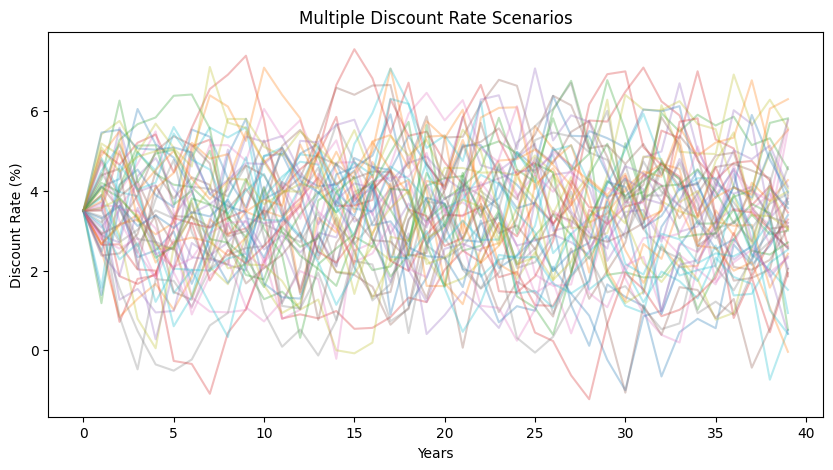

In [ ]:
# Plot the first 50 scenarios
plt.figure(figsize=(10,5))

for i in range(50):plt.plot(all_rates[i] * 100, alpha=0.3)

plt.xlabel("Years")
plt.ylabel("Discount Rate (%)")
plt.title("Multiple Discount Rate Scenarios")

plt.show()

Calculate Pension Entitlement Per Member

In [ ]:
# Calculate each member's annual defined benefit pension entitlement.
# Formula: Annual Pension = Years of Service * Accrual Rate * Final Salary
# We use Accrual Rate = 1/60

# Load dataset
members = pd.read_csv("members.csv")

# Paramters
ACCRUAL_RATE = 1 / 60

# Apply the formula to calculate annual pension
members["Annual_Pension"] = (members["Years_of_Service"] * ACCRUAL_RATE * members["Final_Salary"])
members["Annual_Pension"] = (members["Annual_Pension"].round(2))

# Calculate replacement rate (Pension as Percentage of Final Salary)
members["Replacement_Rate"] = (members["Annual_Pension"] / members["Final_Salary"])

# Save
members.to_csv("members.csv", index=False)

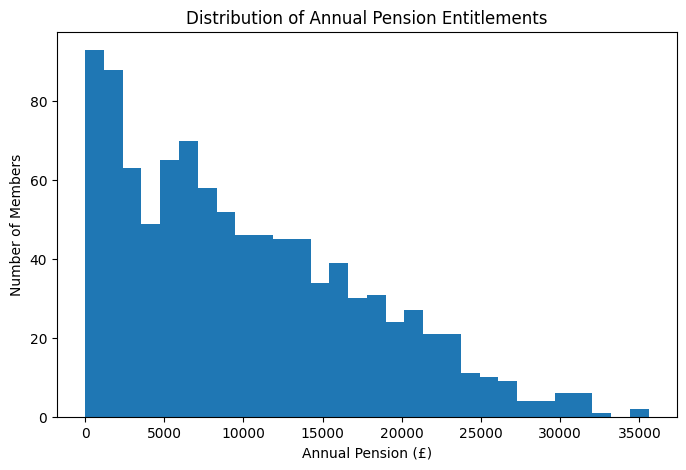

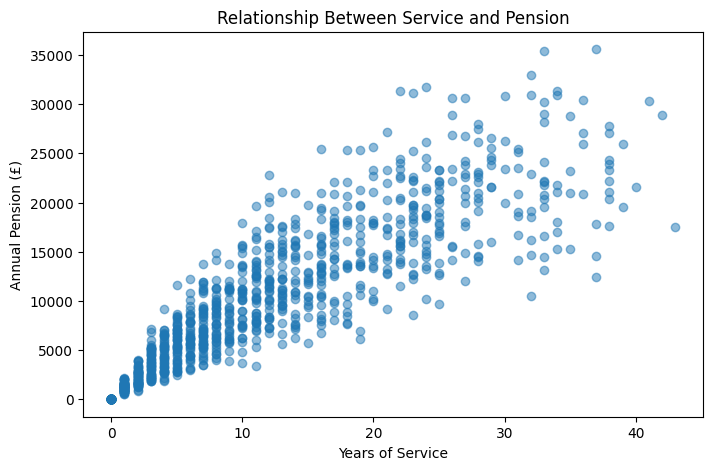

In [ ]:
# Visualise pension distribution
plt.figure(figsize=(8,5))

plt.hist(members["Annual_Pension"], bins=30)

plt.xlabel("Annual Pension (£)")
plt.ylabel("Number of Members")
plt.title("Distribution of Annual Pension Entitlements")

plt.show()

# Visualise pension size by service
plt.figure(figsize=(8,5))

plt.scatter(members["Years_of_Service"], members["Annual_Pension"], alpha=0.5)

plt.xlabel("Years of Service")
plt.ylabel("Annual Pension (£)")
plt.title("Relationship Between Service and Pension")

plt.show()

Calculate Present Value of Pension Liabilities

In [ ]:
# Pension scheme does not owe all pension payments now, future payments must be discounted by inflation and investment returns.

# Formula: Present Value = For each year the pension will be paid (Annual payment / (1 + Discount rate for year t))

# Load dataset
members = pd.read_csv("members.csv")

# Parameters
LONG_RUN_RATE = 0.035
INITIAL_RATE = 0.035

MEAN_REVERSION_SPEED = 0.25
RATE_VOLATILITY = 0.01

# Calculate one members liability
def calculate_member_liability(annual_pension, years_in_retirement, discount_rates):

    pv = 0
    for year in range(1, years_in_retirement + 1):
        discount_factor = (1 + discount_rates[year-1]) ** year
        pv += (annual_pension / discount_factor)

    return pv

# Calculate total liability for one simulation
def simulate_scheme_liability(members):

    total_liability = 0

    max_years = int(members["Years_in_Retirement"].max())
    discount_rates = simulate_discount_rates(max_years)

    for _, member in members.iterrows():
        liability = calculate_member_liability(
            member["Annual_Pension"],
            int(member["Years_in_Retirement"]),
            discount_rates
        )

        # Sum each members liability
        total_liability += liability
    return total_liability

# Run One Test Simulation
liability = simulate_scheme_liability(members)
print(f"Scheme Liability: £{liability:,.0f}")


Scheme Liability: £144,518,046


Run Monte Carlo Simulation

In [ ]:
# Run 10000 possible simulations, with differing salary growth, discount rates, and member longevity.

# Load data
members = pd.read_csv("members.csv")

# Simulate single scenario
def run_single_simulation(members):

    total_liability = 0
    max_years = 40

    # Generate one interest-rate path
    discount_rates = simulate_discount_rates(max_years)

    for _, member in members.iterrows():

        # Project final salary again
        final_salary = project_salary(member["Salary"], member["Age"])

        # Calculate pension entitlement
        annual_pension = (member["Years_of_Service"] *(1/60) * final_salary)

        # Simulate lifetime
        years = np.random.normal(20, 5)
        years = int(round(np.clip(years, 5,40)))
        years_retired = years

        # Calculate PV
        pv = calculate_member_liability(annual_pension, years_retired, discount_rates)

        total_liability += pv

    return total_liability

Liability: £146,482,102


In [ ]:
# Paramters
NUM_SIMULATIONS = 2000

liability_results = np.zeros(NUM_SIMULATIONS)

# Run simulations
for i in range(NUM_SIMULATIONS):
    liability_results[i] = (run_single_simulation(members))

    if i % 100 == 0:
        print(f"Completed {i} simulations")

# Convert to dataframe
simulation_results = pd.DataFrame({
    "Simulation": np.arange(1, NUM_SIMULATIONS + 1),
    "Liability": liability_results
})

# Save
simulation_results.to_csv("liabilities.csv", index=False)


Completed 0 simulations
Completed 100 simulations
Completed 200 simulations
Completed 300 simulations
Completed 400 simulations
Completed 500 simulations
Completed 600 simulations
Completed 700 simulations
Completed 800 simulations
Completed 900 simulations
Completed 1000 simulations
Completed 1100 simulations
Completed 1200 simulations
Completed 1300 simulations
Completed 1400 simulations
Completed 1500 simulations
Completed 1600 simulations
Completed 1700 simulations
Completed 1800 simulations
Completed 1900 simulations


Analyse and Visualise Results

In [ ]:
# Load data
simulation_results = pd.read_csv("liabilities.csv")
members = pd.read_csv("members.csv")

In [ ]:
# Mean liability
mean_liability = (simulation_results["Liability"].mean())
print(f"Mean Liability: £{simulation_results["Liability"].mean():,.0f}")

# Median liability
print(f"Median Liability: £{simulation_results["Liability"].median():,.0f}")

# 95th percentile liability
print(f"95th percentile Liability: £{np.percentile(simulation_results["Liability"], 95):,.0f}")


Mean Liability: £143,243,406
Median Liability: £142,462,537
95th percentile Liability: £161,690,895


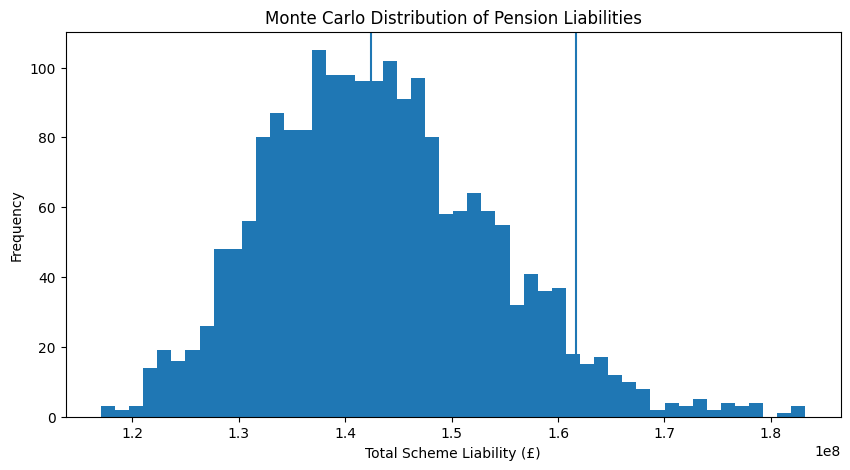

In [ ]:
# Plot distribution of liabilities, shows the uncertainty faced by the scheme
plt.figure(figsize=(10,5))

plt.hist(simulation_results["Liability"], bins=50)

plt.axvline(np.percentile(simulation_results["Liability"],95))
plt.axvline(simulation_results["Liability"].median())

plt.xlabel("Total Scheme Liability (£)")
plt.ylabel("Frequency")
plt.title( "Monte Carlo Distribution of Pension Liabilities")

plt.show()

Scenario Analysis

In [ ]:
# Scenario 1: Discount rates fall by 1 percent

def simulate_lower_discount_rates(years):

    rates = simulate_discount_rates(years)
    rates = rates - 0.01
    rates = np.maximum(rates,0.005)
    return rates

# Calculate stressed liability
def run_discount_rate_stress(members):

    total_liability = 0
    discount_rates = (simulate_lower_discount_rates(40))
    for _, member in members.iterrows():
        pv = calculate_member_liability( member["Annual_Pension"],int(member["Years_in_Retirement"]), discount_rates)
        total_liability += pv
    return total_liability

# Run 1000 stress simulations
discount_stress_results = []
for i in range(1000):
    discount_stress_results.append(run_discount_rate_stress(members))

# Calculate impact
discount_stress_mean = np.mean(discount_stress_results)
increase = (discount_stress_mean - mean_liability)
print(f"Increase in liabilities: £{increase:,.0f}")

Increase in liabilities: £13,460,069


In [ ]:
# Scenario 2 – Longevity Improves by 2 Years
def calculate_longevity_stress_liability(members):

    total_liability = 0
    discount_rates = simulate_discount_rates(40)

    for _, member in members.iterrows():
        stressed_years = (int(member["Years_in_Retirement"]) + 2)
        pv = calculate_member_liability(member["Annual_Pension"], stressed_years, discount_rates)
        total_liability += pv

    return total_liability

longevity_stress_results = []
for i in range(1000):
    longevity_stress_results.append(calculate_longevity_stress_liability(members))

# Calculate impact
longevity_stress_mean = np.mean(longevity_stress_results)
increase = (longevity_stress_mean - mean_liability)
print(f"Increase in liabilities: £{increase:,.0f}")

Increase in liabilities: £11,000,517


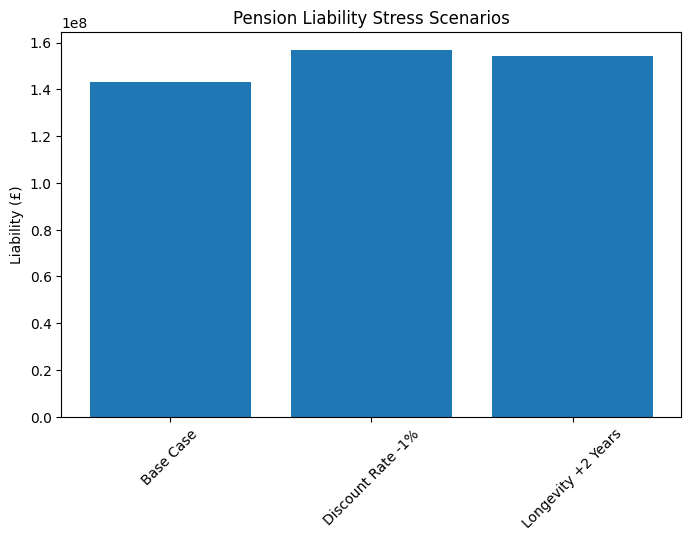

In [ ]:
scenario_summary = pd.DataFrame({

    "Scenario": [
        "Base Case",
        "Discount Rate -1%",
        "Longevity +2 Years"
    ],

    "Mean Liability": [
        mean_liability,
        discount_stress_mean,
        longevity_stress_mean
    ]
})


scenario_summary

# Visualise both scenarios
plt.figure(figsize=(8,5))

plt.bar(scenario_summary["Scenario"], scenario_summary["Mean Liability"])
plt.xticks( rotation=45)

plt.ylabel("Liability (£)")
plt.title("Pension Liability Stress Scenarios")

plt.show()


Funding Shortfall Analysis

In [ ]:
# Given a number of assets, predict the probability of being underfunded

# Paramters
CURRENT_ASSETS = 160_000_000

# Surplus = Assets - Liabilities

simulation_results["Funding_Position"] = (CURRENT_ASSETS - simulation_results["Liability"])

deficit_probability = (simulation_results["Funding_Position"] < 0).mean()
print( f"Probability of deficit: " f"{deficit_probability:.1%}")

Probability of deficit: 6.5%


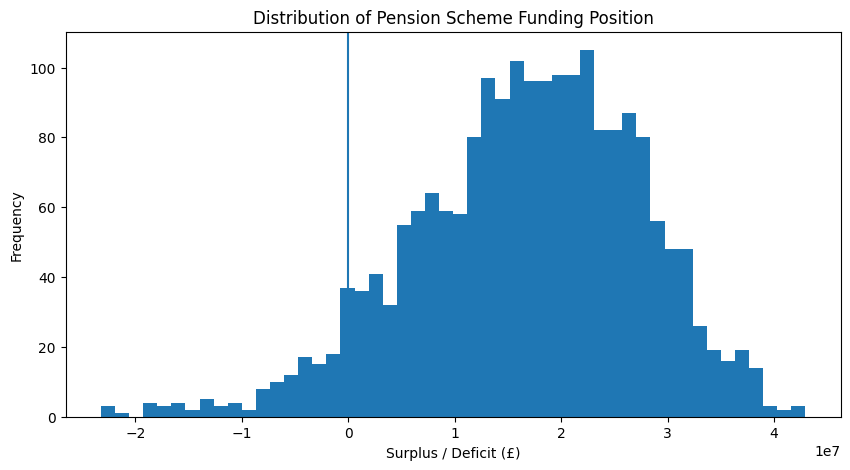

In [ ]:
# Visualise funding distribution
plt.figure(figsize=(10,5))

plt.hist(simulation_results["Funding_Position"],bins=50)

plt.axvline(0)
plt.xlabel("Surplus / Deficit (£)")
plt.ylabel("Frequency")
plt.title("Distribution of Pension Scheme Funding Position")

plt.show()